# Cross-dataset evaluation

Probes trained on one dataset and evaluated on every dataset: Figs 3, 7 and 17–19 of the paper. Final models of the main runs, test split.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from notebook_helper import *

trained = load_trained_cross(split="test")   # trained[eval dataset][train dataset][model][probe] -> runs
acc, cons = load_performance(split="test")

eval on medmcqa4: 100%|██████████| 5/5 [00:08<00:00,  1.71s/it]


In [13]:
def corr_matrix(target, model, probe):
    """Mean over runs of r(confidence, target); rows = training, columns = evaluation dataset."""
    mat = np.full((len(DATASETS), len(DATASETS)), np.nan)
    for i, dt in enumerate(DATASETS):
        for j, de in enumerate(DATASETS):
            corrs = [nan_pearsonr(run["test"]["predictions"], target[de][model])
                     for run in trained[de][dt][model][probe]]
            corrs = [c for c in corrs if not np.isnan(c)]
            if corrs:
                mat[i, j] = np.mean(corrs)
    return mat


# CORR[target][probe][model]: (train, eval) matrix
# DELTA[probe]: (models, train, eval) matrices of Δr = r(conf, accuracy) − r(conf, consistency)
CORR = {name: {p: {m: corr_matrix(target, m, p) for m in MODELS} for p in PROBES}
        for name, target in (("accuracy", acc), ("consistency", cons))}
DELTA = {p: np.stack([CORR["accuracy"][p][m] - CORR["consistency"][p][m] for m in MODELS])
         for p in PROBES}
SHORT = [SHORT_LABELS[d] for d in DATASETS]

## Figs 3 and 7 — Δr in and out of distribution
One panel per training dataset, mean ± SEM over models. Black outline: in-distribution (train = eval).

In [14]:
FS = dict(base=19, title=20, label=21, tick=18, legend=18)
n = len(DATASETS)


def plot_cross(probes, name):
    """One probe: bars coloured by the sign of Δr. Several probes: one colour per probe."""
    set_style(FS)
    means = {p: np.mean(DELTA[p], axis=0) for p in probes}
    errs = {p: sem(DELTA[p], axis=0) for p in probes}
    vlim = np.ceil(max(np.nanmax(np.abs(means[p]) + np.nan_to_num(errs[p]))
                       for p in probes) * 10) / 10
    offsets, slot = bar_offsets(len(probes), group_width=0.78)

    fig, axs = plt.subplots(1, n, figsize=(17, 6.2), sharey=True, layout="constrained")
    fig.get_layout_engine().set(wspace=0.04, h_pad=0.08)
    x = np.arange(n)
    for i, ax in enumerate(axs):
        ax.axhline(0, color="black", lw=1.0, zorder=2)
        for p, off in zip(probes, offsets):
            color = (COLORS[p] if len(probes) > 1 else
                     [COLORS["red"] if v > 0 else COLORS["steel"] for v in means[p][i]])
            bars = ax.bar(x + off, means[p][i], yerr=errs[p][i], width=0.9 * slot,
                          color=color, edgecolor="none", zorder=3, error_kw=ERR_KW)
            bars[i].set_edgecolor("black")      # in-distribution
            bars[i].set_linewidth(2.0)
        ax.set_title(f"train: {SHORT[i]}", pad=10)
        ax.set_xticks(x)
        ax.set_xticklabels(SHORT, rotation=35, ha="right", rotation_mode="anchor")
        ax.tick_params(axis="x", length=0)
        ax.set_xlim(-0.6, n - 0.4)
        style_ax(ax, lw=0.8)
        if i:
            ax.tick_params(axis="y", length=0)
    axs[0].set_ylim(-vlim, vlim)
    axs[0].set_ylabel("Δ Pearson r\n(accuracy − consistency)")

    if len(probes) > 1:
        handles = [Patch(facecolor=COLORS[p], label=PROBE_LABELS[p]) for p in probes]
        xlabel = "evaluation dataset   ·   Δr > 0: tracks accuracy more"
    else:
        handles = [Patch(facecolor=COLORS["red"], label="Δr > 0: tracks accuracy more"),
                   Patch(facecolor=COLORS["steel"], label="Δr < 0: tracks consistency more")]
        xlabel = "evaluation dataset"
    handles.append(Patch(facecolor="white", edgecolor="black", lw=2.0,
                         label="in-distribution (train = eval)"))
    fig.legend(handles=handles, loc="outside upper center", ncols=len(handles), frameon=False,
               handlelength=1.4, handleheight=1.0, columnspacing=2.0)
    fig.supxlabel(xlabel, fontsize=FS["label"])
    save_fig(fig, name)
    plt.show()

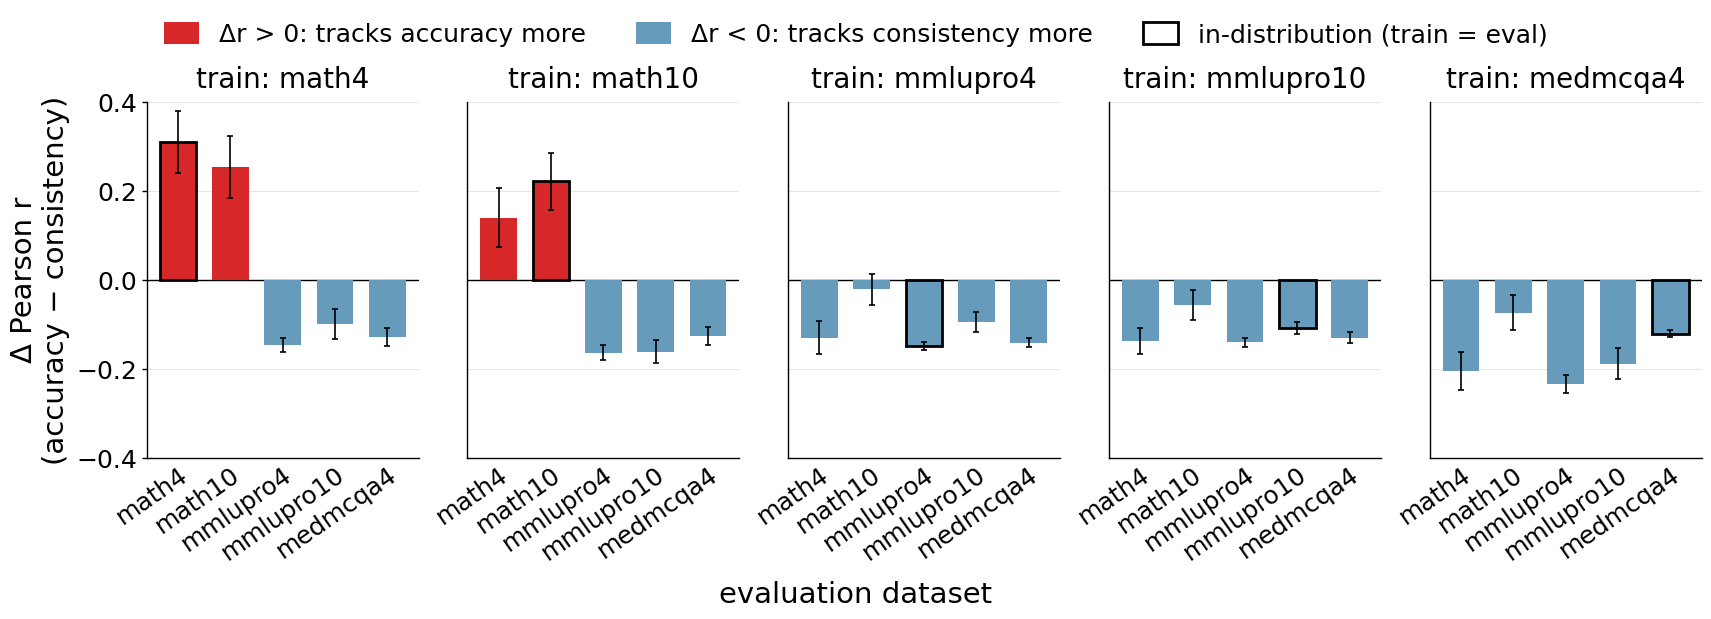

In [15]:
plot_cross(["end"], "fig03_cross_eval_end")

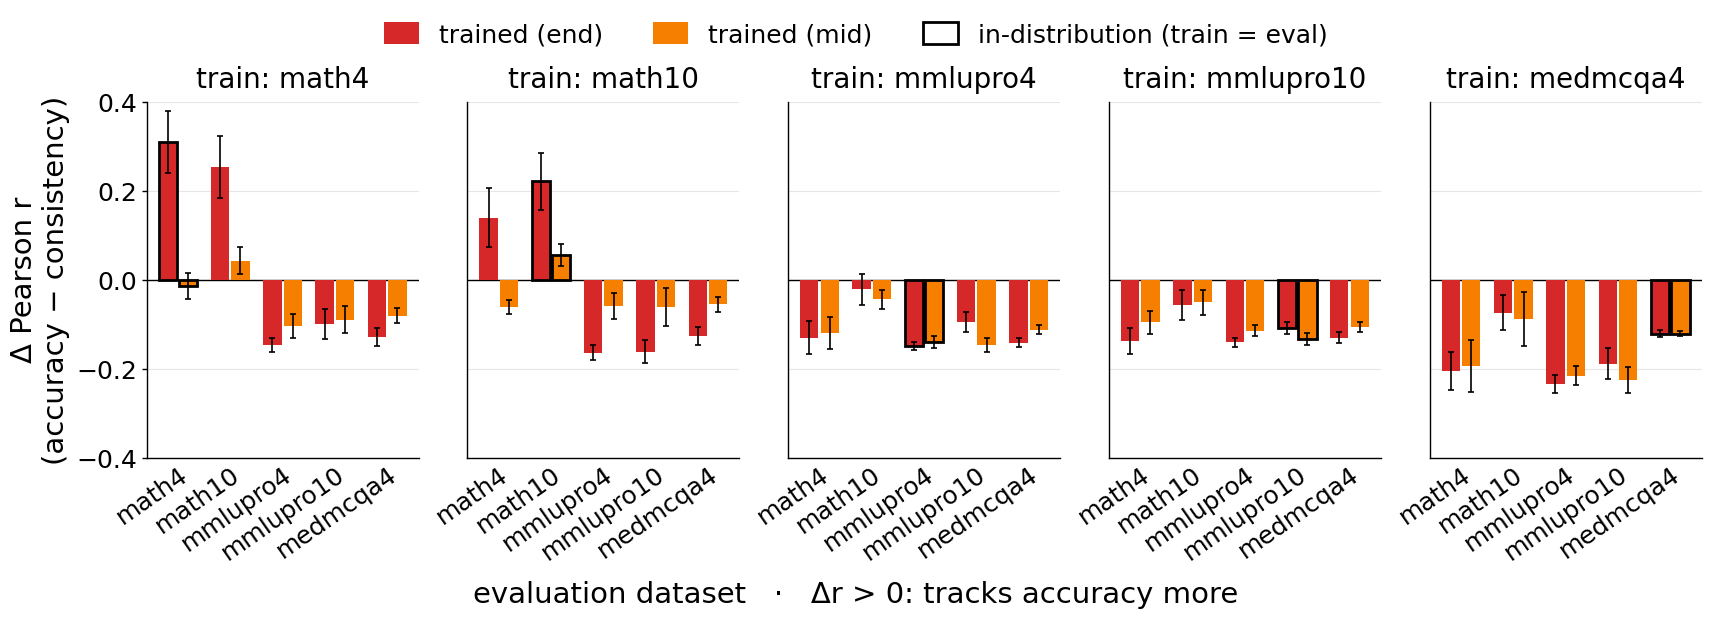

In [16]:
plot_cross(["end", "mid"], "fig07_cross_eval_end_mid")

In [22]:
# Δr over groups of (train, eval) cells: average per model, then mean ± SEM over models
def cells(train, evals):
    mask = np.zeros((n, n), dtype=bool)
    mask[np.ix_(train, evals)] = True
    return mask


math = [SHORT.index("math4"), SHORT.index("math10")]
other = [i for i in range(n) if i not in math]
GROUPS = {
    "math → math": cells(math, math),
    "math → other": cells(math, other),
    "other → all": cells(other, range(n)),
}
for p in ["end", "mid"]:
    print(f"probe {p}: Δr, mean ± SEM over {len(MODELS)} models")
    for name, mask in GROUPS.items():
        v = np.array([np.nanmean(d[mask]) for d in DELTA[p]])
        print(f"  {name:<20} {np.nanmean(v):+.3f} ± {sem(v):.3f}")

probe end: Δr, mean ± SEM over 10 models
  math → math          +0.231 ± 0.065
  math → other         -0.138 ± 0.020
  other → all          -0.129 ± 0.015
probe mid: Δr, mean ± SEM over 10 models
  math → math          +0.005 ± 0.021
  math → other         -0.075 ± 0.024
  other → all          -0.127 ± 0.018


## Figs 17–19 — Transfer heatmaps
Per-model matrices for each probe (rows = training, columns = evaluation dataset) and their mean ± SEM over models. Black boxes: in-distribution.

In [18]:
HEATMAP_RC = {"font.size": 8, "axes.titlesize": 8, "axes.labelsize": 10,
              "xtick.labelsize": 6, "ytick.labelsize": 6, "axes.linewidth": 0.4,
              "xtick.major.width": 0.4, "ytick.major.width": 0.4}
MODEL_ROWS, MODEL_COLS = 5, 2        # layout of the 10 models inside a probe block


def draw_matrix(ax, mat, err=None, vmin=-1, vmax=1, fontsize=5.2, err_fontsize=4.0, ticks=True):
    """Annotated heatmap with the in-distribution diagonal boxed."""
    im = ax.imshow(mat, vmin=vmin, vmax=vmax, cmap="RdBu_r", aspect="auto")
    k = mat.shape[0]
    ax.set_xticks(range(k))
    ax.set_yticks(range(k))
    if ticks:
        ax.set_xticklabels(SHORT, rotation=45, ha="right", rotation_mode="anchor")
        ax.set_yticklabels(SHORT)
    else:
        ax.set_xticklabels([])
        ax.set_yticklabels([])
    ax.tick_params(length=1.5, pad=1)
    for spine in ax.spines.values():
        spine.set_linewidth(0.4)
    for i in range(k):
        ax.add_patch(plt.Rectangle((i - 0.5, i - 0.5), 1, 1, fill=False, edgecolor="black",
                                   lw=0.9, zorder=4))
    span = max(abs(vmin), abs(vmax))
    for i in range(k):
        for j in range(k):
            if np.isnan(mat[i, j]):
                continue
            color = "white" if abs(mat[i, j]) > 0.55 * span else "black"
            if err is None or np.isnan(err[i, j]):
                ax.text(j, i, f"{mat[i, j]:.2f}", ha="center", va="center",
                        fontsize=fontsize, color=color, zorder=5)
            else:                               # mean, and ± SEM just below
                ax.text(j, i, f"{mat[i, j]:.2f}", ha="center", va="bottom",
                        fontsize=fontsize, color=color, zorder=5)
                ax.text(j, i, f"±{err[i, j]:.2f}", ha="center", va="top",
                        fontsize=err_fontsize, color=color, alpha=0.85, zorder=5)
    return im


def heatmap_blocks(matrix_fn, cbar_label, name, vmin=-1, vmax=1):
    """A4 figure: 5 x 2 per-model heatmaps per probe, model average (mean ± SEM) below."""
    probes = ["end", "mid"]
    width_ratios, col_of = [], []               # spacer column between the probe blocks
    for b in range(len(probes)):
        if b:
            width_ratios.append(0.10)
        col_of.append(len(width_ratios))
        width_ratios += [1.0] * MODEL_COLS

    with plt.rc_context(HEATMAP_RC):
        fig = plt.figure(figsize=(7.9, 10.9), layout="constrained")
        fig.get_layout_engine().set(w_pad=0.005, h_pad=0.005, wspace=0.008, hspace=0.008)
        gs = fig.add_gridspec(MODEL_ROWS + 2, len(width_ratios), width_ratios=width_ratios,
                              height_ratios=[0.22] + [1] * MODEL_ROWS + [1.8])
        for b, probe in enumerate(probes):
            c0 = col_of[b]
            hax = fig.add_subplot(gs[0, c0:c0 + MODEL_COLS])
            hax.set_axis_off()
            hax.text(0.5, 0.15, f"probe: {probe}", ha="center", va="center", fontsize=11,
                     weight="bold")
            for k, model in enumerate(MODELS):
                i, j = divmod(k, MODEL_COLS)
                ax = fig.add_subplot(gs[1 + i, c0 + j])
                im = draw_matrix(ax, matrix_fn(probe, model), vmin=vmin, vmax=vmax, ticks=False)
                if j == 0 and b == 0:           # dataset names on the outer panels only
                    ax.set_yticklabels(SHORT)
                if i == MODEL_ROWS - 1:
                    ax.set_xticklabels(SHORT, rotation=45, ha="right", rotation_mode="anchor")
                ax.set_title(model, pad=2, fontsize=7 if len(model) <= 20 else 5.9)

            stack = np.stack([matrix_fn(probe, m) for m in MODELS])
            ax = fig.add_subplot(gs[-1, c0:c0 + MODEL_COLS])
            draw_matrix(ax, np.mean(stack, axis=0), err=sem(stack, axis=0), vmin=vmin,
                        vmax=vmax, fontsize=8.5, err_fontsize=6.0)
            if b:
                ax.set_yticklabels([])
            ax.tick_params(labelsize=8)
            ax.set_title(f"mean ± SEM over {len(MODELS)} models", fontsize=9.5, weight="bold",
                         pad=3)

        fig.supylabel("training dataset", fontsize=11)
        fig.supxlabel("evaluation dataset", fontsize=11)
        cbar = fig.colorbar(im, ax=fig.axes, shrink=0.55, pad=0.008, aspect=45, location="right")
        cbar.set_label(cbar_label, fontsize=9)
        cbar.ax.tick_params(labelsize=8)
        save_fig(fig, name, dpi=400)
    plt.show()

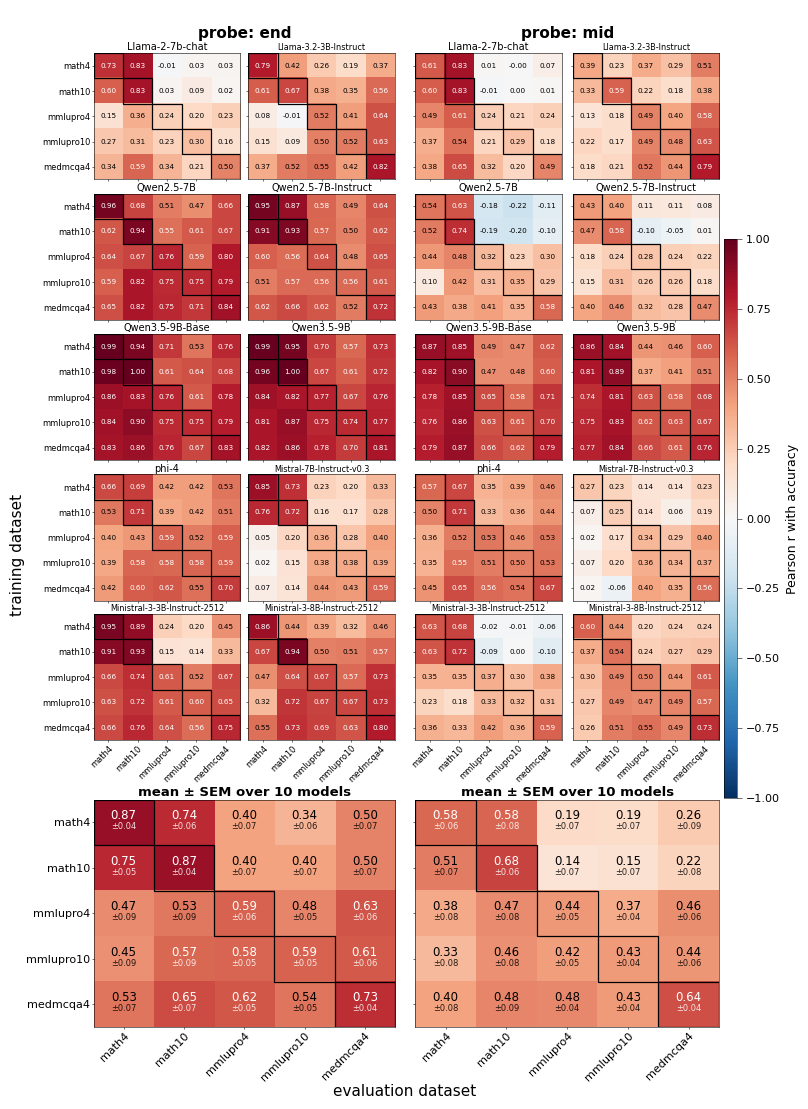

In [19]:
heatmap_blocks(lambda p, m: CORR["accuracy"][p][m], "Pearson r with accuracy",
               "fig17_cross_heatmap_accuracy")

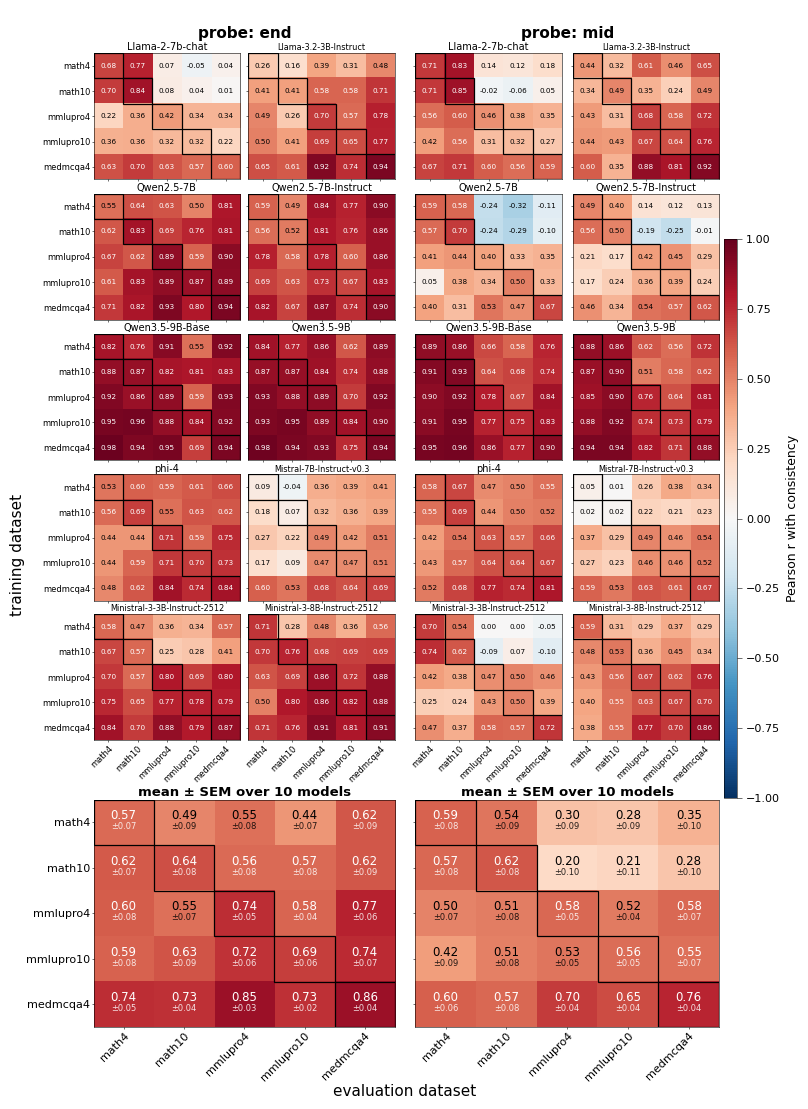

In [20]:
heatmap_blocks(lambda p, m: CORR["consistency"][p][m], "Pearson r with consistency",
               "fig18_cross_heatmap_consistency")

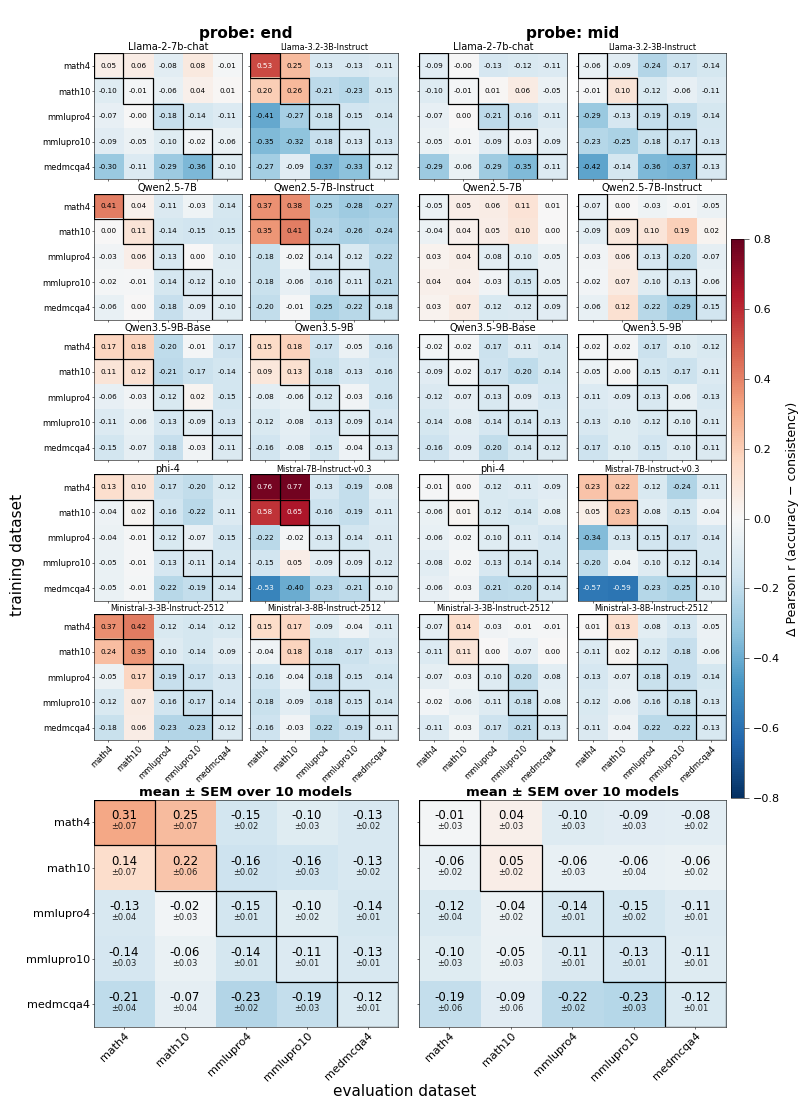

In [21]:
vlim = np.ceil(max(np.nanmax(np.abs(DELTA[p])) for p in ("end", "mid")) * 10) / 10
heatmap_blocks(lambda p, m: DELTA[p][MODELS.index(m)], "Δ Pearson r (accuracy − consistency)",
               "fig19_cross_heatmap_delta", vmin=-vlim, vmax=vlim)